### 2.7 Resolution Sensitivity

This section answers the part of the task that asks explicitly to *"show how these patterns vary in different spatio-temporal resolution (census tract vs. varying hexagon diameter and/or temporal bin sizes)"*. It is therefore not an appendix but a core deliverable.

**One distinction up front.** Not every pattern reacts to resolution the same way. Trip-attribute *distributions* (length, price, duration) are essentially resolution-invariant at city level - a trip's length does not change because space is binned differently. What genuinely changes with resolution is (i) the **demand count** per unit and its sparsity, and (ii) the **spatial distribution** of per-area aggregates. This subsection therefore focuses on demand counts and spatial concentration; the resolution-invariant trip distributions were already shown in the baseline block and 2.1.

**Why spatial is weighted more than temporal.** Spatial aggregation is a structural choice - different grids (hexagon diameters, administrative areas) have different shapes, sizes and data coverage. Temporal aggregation is a smoothing operation: variance falls with the bin width but the daily cycle keeps its shape. The spatial sweep is therefore the substantive one; the temporal sweep is kept short.

Three blocks follow: **A** spatial sweep (incl. census tract), **B** temporal sweep, **C** GMM hotspots vs grid. The closing block gives the recommended resolution.

> **Data dependency:** this section re-aggregates from the trip-level export `df_trips_full.parquet`. Sparsity per (cell x time bucket) cannot be read off the time-collapsed per-cell totals saved for the choropleths, so the trip-level frame is required (the same export that 2.6 already loads). The zero-rate is computed in closed form - `1 - observed / (cells x buckets)` - so the expensive full zero-fill grid is never materialised, which keeps even r8 x 1h tractable.

In [1]:
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROCESSED = pathlib.Path("../processed")

# trip-level frame (cell ids r4-r8 + community area + census tract + timestamp + trip chars)
trips = pd.read_parquet(PROCESSED / "df_trips_full.parquet")

FREQ = {"time_1h": "h", "time_4h": "4h", "time_8h": "8h", "time_1d": "D"}


def gini(values):
    """Gini coefficient of a 1-D array of non-negative values (0 = equal, ->1 = concentrated)."""
    x = np.sort(np.asarray(values, dtype="float64"))
    n = x.size
    if n == 0 or x.sum() == 0:
        return np.nan
    return (2 * np.sum(np.arange(1, n + 1) * x) / (n * x.sum())) - (n + 1) / n


def resolution_stats(trips, spatial_col, time_col):
    """Descriptive sparsity + concentration for one (spatial, temporal) resolution.
    Zero-rate is closed-form (no zero-fill materialised)."""
    t = trips.dropna(subset=[spatial_col])
    bucket = t["trip_start_timestamp"].dt.floor(FREQ[time_col])

    obs = t.groupby([spatial_col, bucket], observed=True).size()           # observed (cell,bucket) counts
    n_cells = int(t[spatial_col].nunique())
    n_buckets = len(pd.date_range(bucket.min(), bucket.max(), freq=FREQ[time_col]))
    zero_rate = 1 - len(obs) / (n_cells * n_buckets)

    per_cell = t.groupby(spatial_col, observed=True).size().sort_values(ascending=False)
    top10 = per_cell.head(max(1, int(0.10 * n_cells))).sum() / per_cell.sum()

    return {"spatial": spatial_col, "temporal": time_col, "n_cells": n_cells,
            "n_buckets": n_buckets, "zero_rate": zero_rate,
            "median_demand": float(obs.median()), "p99_demand": float(obs.quantile(0.99)),
            "gini_per_cell": gini(per_cell.values), "top10pct_share": top10,
            "coverage": len(t) / len(trips)}


#### 2.7a Spatial sweep at fixed 4-hour bins

H3 r4 (coarse) -> r6 -> r8 (fine), plus Community Area and Census Tract, all at 4-hour buckets. The table reports the number of cells, the closed-form zero-rate, median and 99th-percentile demand, the Gini of per-cell demand, the share held by the busiest 10% of cells, and the trip coverage of each spatial key.

**Census tract is included as the task names it explicitly - but with two caveats.** First, `pickup_census_tract` is missing for ~55% of trips (1.3), so its `coverage` is far below 1 and its absolute demand is understated. Second, the missingness is not random: Chicago suppresses the tract precisely when few trips occur there, so it is correlated with low demand and cannot be rescaled by `1/coverage` without distorting the spatial distribution. Census tract is therefore reported for completeness and **not** used as a primary unit - consistent with 1.3.

In [2]:
spatial_res = pd.DataFrame([
    resolution_stats(trips, sp, "time_4h")
    for sp in ["h3_r4", "h3_r6", "h3_r8", "pickup_community_area", "pickup_census_tract"]
])
spatial_res.round(3)


,spatial,temporal,n_cells,n_buckets,zero_rate,median_demand,p99_demand,gini_per_cell,top10pct_share,coverage
0,h3_r4,time_4h,4,4927,0.018,88.0,4788.40,0.629,0.777,1.000
1,h3_r6,time_4h,27,4927,0.126,16.0,2303.00,0.810,0.675,1.000
2,h3_r8,time_4h,475,4927,0.820,6.0,484.00,0.947,0.941,1.000
3,pickup_community_area,time_4h,77,4927,0.173,6.0,984.00,0.841,0.802,0.999
4,pickup_census_tract,time_4h,607,4927,0.947,9.0,480.78,0.976,0.995,0.456


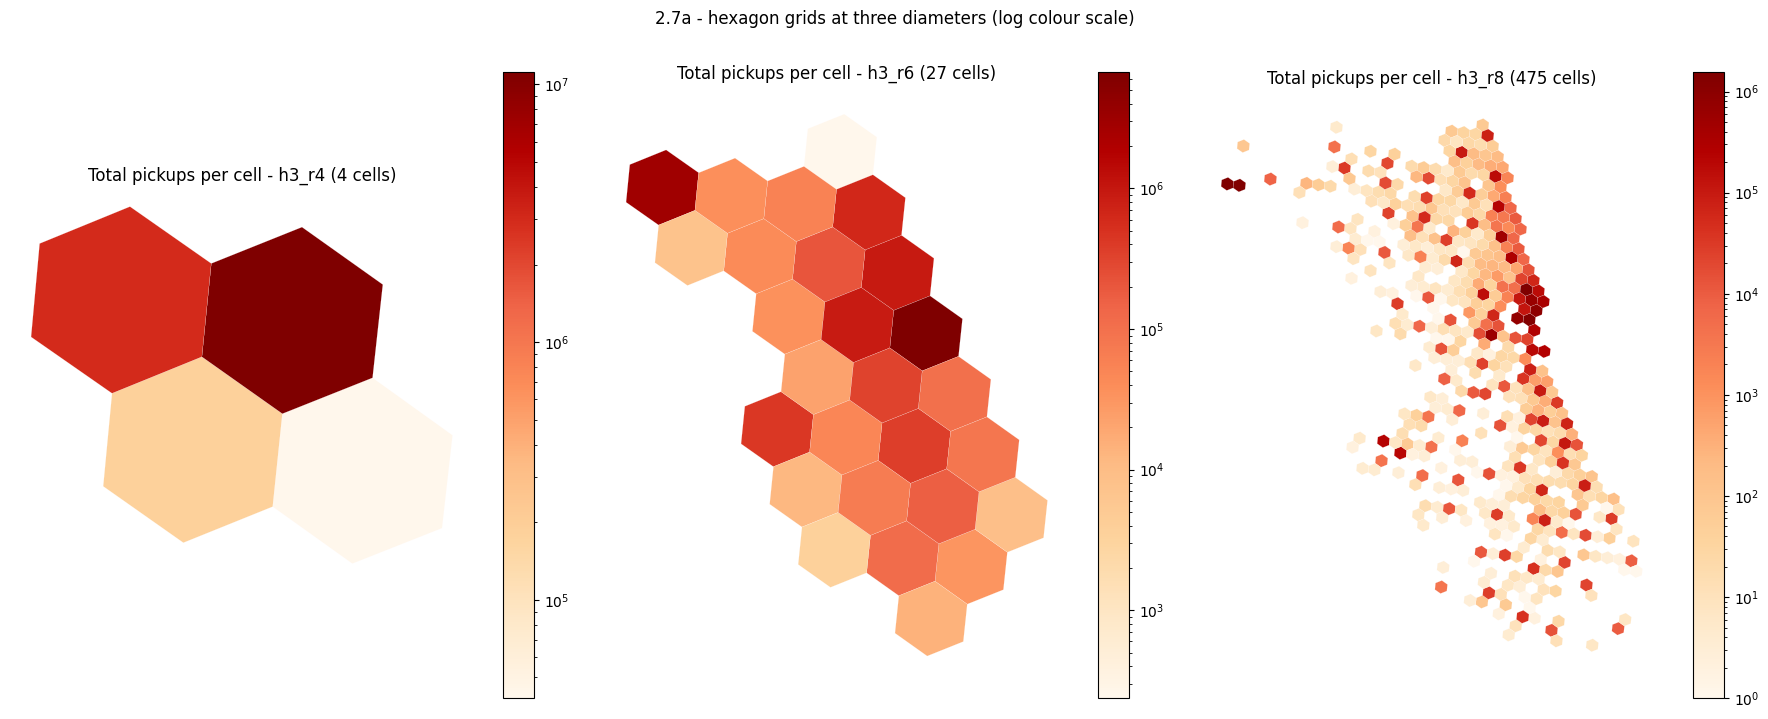

In [3]:
# Choropleth small-multiples: total pickups per cell at r4 / r6 / r8 (hexagon grids, no GeoJSON needed)
import h3
import geopandas as gpd
from shapely.geometry import Polygon
from matplotlib.colors import LogNorm


def h3_poly(cell):
    return Polygon([(lon, lat) for lat, lon in h3.cell_to_boundary(cell)])   # h3 v4


fig, axes = plt.subplots(1, 3, figsize=(18, 7))
for ax, res in zip(axes, ["h3_r4", "h3_r6", "h3_r8"]):
    tot = trips.groupby(res, observed=True).size().rename("n_trips").reset_index()
    tot["geometry"] = tot[res].apply(h3_poly)
    gdf = gpd.GeoDataFrame(tot, geometry="geometry", crs="EPSG:4326")
    gdf.plot(column="n_trips", cmap="OrRd", legend=True, linewidth=0.1, edgecolor="white",
             norm=LogNorm(vmin=max(1, tot["n_trips"].min()), vmax=tot["n_trips"].max()), ax=ax)
    ax.set_title(f"Total pickups per cell - {res} ({len(tot)} cells)")
    ax.set_axis_off()
plt.suptitle("2.7a - hexagon grids at three diameters (log colour scale)", y=1.02)
plt.tight_layout(); plt.show()


*Reading.* As the hexagon shrinks the grid explodes and demand fragments: r4 = **4 cells** (zero-rate 1.8%, Gini 0.63), r6 = 27 cells (12.6%, Gini 0.81), r8 = **475 cells, 82.0% of (cell x 4h) buckets empty**, Gini 0.95, with the busiest 10% of cells holding 94% of demand. Concrete reasons: at r4 the whole Loop, Near North and the lakefront collapse into one or two cells (no operational detail); at r8 a single demand centre such as O'Hare is split across several cells, so its total is diluted and the per-cell series becomes noisy. Community Area (77 cells, Gini 0.84) sits close to r6. Census tract is the extreme - **607 cells, 94.7% empty, Gini 0.98**, and only 46% trip coverage - confirming it is unusable as a primary unit.

#### 2.7b Temporal sweep at fixed H3 r6

The spatial unit is held at r6 and the time bucket widened from 1h to 4h, 8h and 1d. Because this is a smoothing operation, the expectation is monotone: zero-rate falls and median demand rises with the bin width, while the daily-cycle shape (already shown at 1h vs 4h in 2.1) is preserved, only flattened.

In [4]:
temporal_res = pd.DataFrame([
    resolution_stats(trips, "h3_r6", tc)
    for tc in ["time_1h", "time_4h", "time_8h", "time_1d"]
])
temporal_res.round(3)


,spatial,temporal,n_cells,n_buckets,zero_rate,median_demand,p99_demand,gini_per_cell,top10pct_share,coverage
0,h3_r6,time_1h,27,19705,0.268,6.0,597.00,0.81,0.675,1.0
1,h3_r6,time_4h,27,4927,0.126,16.0,2303.00,0.81,0.675,1.0
2,h3_r6,time_8h,27,2464,0.078,29.0,4142.90,0.81,0.675,1.0
3,h3_r6,time_1d,27,822,0.040,91.0,9909.34,0.81,0.675,1.0


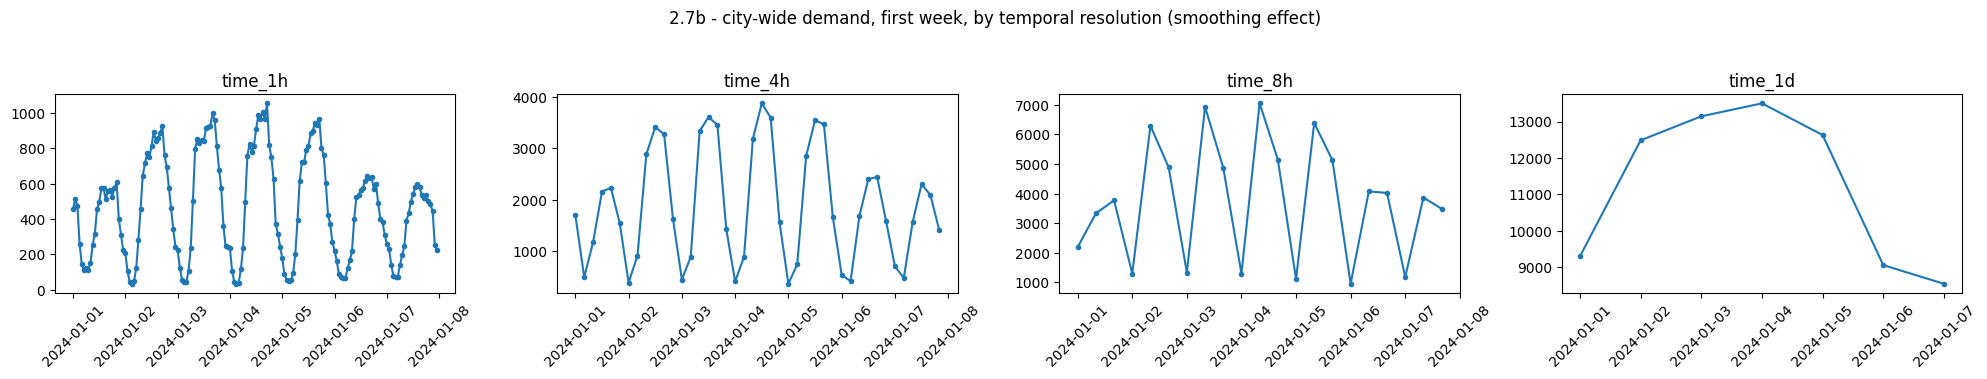

In [5]:
# City-level demand over one representative week at the four temporal resolutions
fig, axes = plt.subplots(1, 4, figsize=(20, 3.6))
for ax, tc in zip(axes, ["time_1h", "time_4h", "time_8h", "time_1d"]):
    s = trips.groupby(trips["trip_start_timestamp"].dt.floor(FREQ[tc]), observed=True).size()
    week = s[(s.index >= s.index.min()) & (s.index < s.index.min() + pd.Timedelta(days=7))]
    ax.plot(week.index, week.values, marker="o", ms=3)
    ax.set_title(tc); ax.tick_params(axis="x", rotation=45)
plt.suptitle("2.7b - city-wide demand, first week, by temporal resolution (smoothing effect)", y=1.04)
plt.tight_layout(); plt.show()


*Reading.* From 1h to 1d the zero-rate falls **26.8% -> 12.6% -> 7.8% -> 4.0%** and the median demand per bucket rises **6 -> 16 -> 29 -> 91**, while the per-cell Gini stays at **0.81** throughout - temporal aggregation smooths the counts but does not change the spatial concentration. The 1h view shows the sharp commuting and late-evening peaks; by 1d these are flattened into one point per day and the tactical signal (when to deploy within a day) is gone. 4h keeps enough intra-day structure for shift planning while roughly halving the zero-rate of 1h - the practical compromise also chosen in Task 1.

**Note on idle time.** The task lists *average idle time between trips* among the patterns to study. Idle is a per-taxi quantity (gap between one taxi's consecutive trips), not a per-cell count, so binning space or time finer only re-averages the same values into noisier bins without revealing new structure. Idle is therefore analysed on its natural axes - over time in 2.1 and over space (per Community Area) in 2.6 - and is deliberately not part of this resolution sweep.

#### 2.7c GMM hotspots vs grid hotspots

The Gaussian-Mixture hotspots from 2.2 are independent of any grid. Overlaying their centres on the top-10 cells of each hexagon resolution shows how grid choice distorts the apparent hotspots: a coarse grid (r4) merges separate centres into one cell, a fine grid (r8) splits a single centre across many cells. A small GMM is refitted here on a coordinate sample so the block is self-contained and mirrors 2.2.

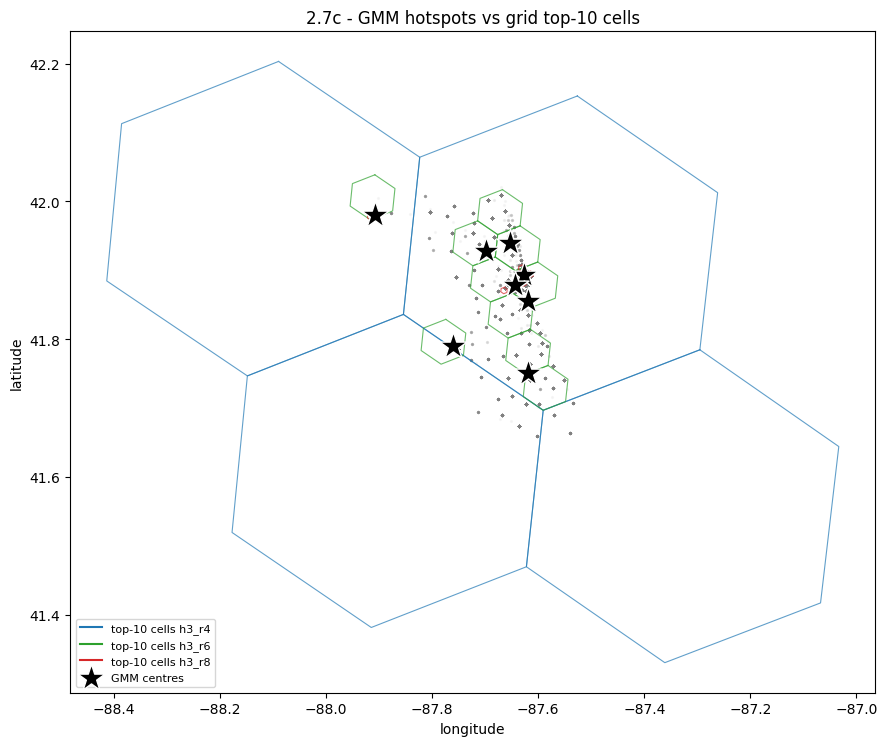

In [6]:
from sklearn.mixture import GaussianMixture

coords = trips[["pickup_centroid_latitude", "pickup_centroid_longitude"]].dropna()
samp = coords.sample(min(50_000, len(coords)), random_state=42)
gmm = GaussianMixture(n_components=8, covariance_type="full", random_state=42).fit(samp.values)
centres = gmm.means_

fig, ax = plt.subplots(figsize=(9, 10))
ax.scatter(samp["pickup_centroid_longitude"], samp["pickup_centroid_latitude"],
           s=2, alpha=0.05, color="grey")
for res, col in [("h3_r4", "#1f77b4"), ("h3_r6", "#2ca02c"), ("h3_r8", "#d62728")]:
    top = trips.groupby(res, observed=True).size().sort_values(ascending=False).head(10).index
    for c in top:
        b = h3.cell_to_boundary(c)
        ax.plot([lon for lat, lon in b] + [b[0][1]],
                [lat for lat, lon in b] + [b[0][0]], color=col, lw=0.8, alpha=0.7)
    ax.plot([], [], color=col, label=f"top-10 cells {res}")
ax.scatter(centres[:, 1], centres[:, 0], marker="*", s=420, c="black",
           edgecolor="white", zorder=5, label="GMM centres")
ax.set(title="2.7c - GMM hotspots vs grid top-10 cells", xlabel="longitude", ylabel="latitude")
ax.set_aspect(1.3); ax.legend(loc="lower left", fontsize=8)
plt.tight_layout(); plt.show()


*Reading.* The GMM centres land on the genuine demand cores (Loop, O'Hare, Midway, Near North). The r4 top-10 cells are too blunt to separate Loop from Near North; the r8 top-10 cells cluster several around one airport, over-counting it. r6 aligns most closely with the GMM centres - one more argument for r6 as the working resolution. (Read off the map above: the GMM centres are grid-independent, the outlined cells are not.)

#### Recommendation

Across the three blocks, **H3 r6 x 4h** is the resolution that best balances spatial detail against sparsity: fine enough to separate the real demand cores (2.7c) yet not so fine that the demand panel becomes dominated by empty buckets (2.7a/b). Coarser hexagons (r4) and daily bins lose the operational signal; finer hexagons (r8) and hourly bins inflate the zeros. Community Area remains useful for interpretation and for the OD/per-area views (2.4, 2.6) because it is human-readable, and census tract is documented but unsuitable as a primary unit. This is the resolution carried into the predictive modelling in Task 3.

### 2.8 Summary and Implications

This section consolidates the descriptive findings (2.1-2.7) into the three decision layers the client - a car manufacturer building an electric ride-hailing fleet - actually faces. The framing follows the strategic / tactical / operational split from 1.1. Throughout, the point is the *"so what"*: each finding ends in an implication, not just a description.

#### Strategic - where to enter the market first

Demand is highly concentrated: a small number of areas (the Loop and Near North downtown core, and the two airports O'Hare and Midway) account for a large share of all pickups, and they stay dominant across hours and weeks (2.2, 2.3, 2.7a). The GMM hotspots (2.2, 2.7c) confirm these as genuine spatial cores rather than grid artefacts.

*Implication:* a phased market entry should start with the downtown core plus the airport corridors. These offer the highest, most reliable demand density - the safest place to commit the first vehicles and the first charging capital. Outer neighbourhoods are thinner and more volatile and are better served later.

#### Tactical - when and how many vehicles, where

Demand follows strong and predictable cycles: a weekday commuting profile distinct from the weekend leisure profile, clear intra-day peaks, and a seasonal/monthly component (2.1, 2.3). Weather modulates this on top of the calendar - cold and light rain lift demand, heavy snow suppresses it - and this effect is real even after controlling for time of day (2.5).

*Implication:* fleet size should be planned per shift and per area, not as a flat number. The heatmap matrix (2.3) is effectively a deployment schedule: which cells need vehicles at which hours. Weather-aware buffers are worthwhile because the weather signal is genuine, not a time-of-day artefact.

#### Operational - repositioning, idle time, charging

The origin-destination flows are asymmetric (2.4): some corridors carry far more traffic one way than the other, so vehicles accumulate at destinations and must be repositioned back empty. Idle time is high in low-demand hours and in peripheral areas (2.1, 2.6), marking local over-supply. Per-area trip characteristics differ sharply (2.6): the core produces many short, high-throughput trips, the airports fewer but long, high-value ones.

*Implication:* repositioning should target the high-asymmetry corridors, and charging is best scheduled into the high-idle windows and locations, where vehicles already sit unused. The short-trip core favours high vehicle turnover; the long-trip airport runs favour range and charge planning - two different operating regimes within one city.

#### Possible reasons for the observed patterns

Consolidated causal reading: the weekday morning/evening peaks reflect commuting; the downtown concentration reflects business and nightlife density; the airport hotspots reflect inbound/outbound travel with long, high-fare trips; the weekend shift reflects leisure travel later in the day; the weather lift reflects substitution away from walking and transit in poor conditions. These are hypotheses supported by the data, consistent with the urban-mobility literature, and would be confirmed with point-of-interest data (a documented next step).

#### Limitations and bridge to Task 3

- **Weather** is from a single city-centre station (1.5); fine spatial weather differences within Chicago are not captured, which is acceptable at 4h granularity but a limitation for finer work.
- **Census tract** is structurally incomplete (~55% suppressed, demand-correlated), so any tract-level absolute demand is understated and not rescalable (2.7a).
- **Sample period** limits the seasonal coverage; rare high-demand events are under-represented.

**Bridge to Task 3.** The resolution analysis (2.7) selects **H3 r6 x 4h** as the modelling unit, and the descriptive structure here - strong calendar cycles, a genuine weather effect, stable spatial cores - defines the feature space (calendar, weather, location) for the predictive models that follow.